In [21]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)

import easyocr
reader = easyocr.Reader(['es'], gpu=True)
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


False
None


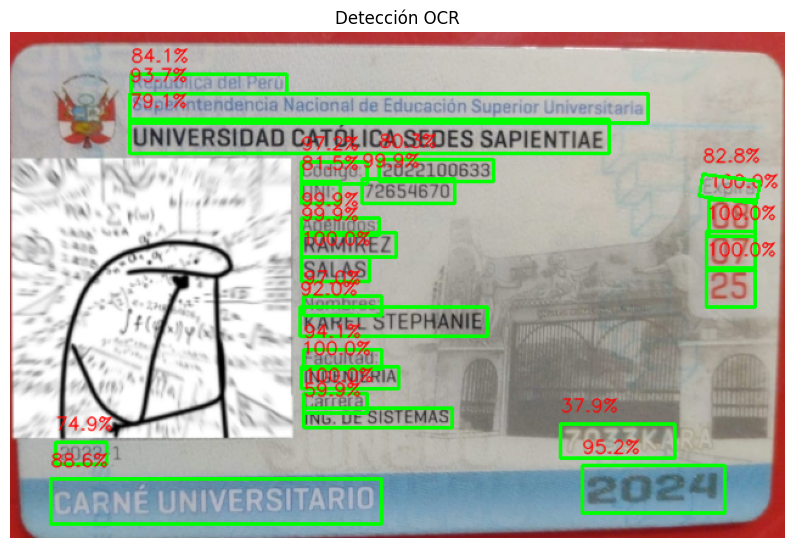

Republica del Peru
Superintendencia Nacional de Educacion Superior Universitaria
UNIVERSIDAD CATÓLICA SEDES SAPIENTIAE
Codigo:
2022100633
DNI:
72654670
Apellidos
08
RAMIREZ
07
SALAS
25
Nombres
KAREL STEPHANIE
Facultad:
INGENIERIA
Carrera
ING. DE SISTEMAS
2022
7o33ka
CARNÉ UNIVERSITARIO
2024
Expira



In [77]:

img_path = "../img_test/OCR/karel.jpg"
image = cv2.imread(img_path)


# Redimensionar la imagen (por ejemplo, al 50% del tamaño original)
scale_percent = 50  # Cambia este valor según lo que necesites
width = int(image.shape[1] * scale_percent / 100)
height = int(image.shape[0] * scale_percent / 100)
dim = (width, height)
image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

result = reader.readtext(image)

texto = ""

for (bbox, text, prob) in result:
    # bbox es una lista de 4 puntos (esquinas del rectángulo)
    pts = np.array(bbox, dtype=np.int32)
    pts = pts.reshape((-1, 1, 2))
    # Dibujar el contorno (cuadrícula)
    cv2.polylines(image, [pts], isClosed=True, color=(0,255,0), thickness=2)
    # Mostrar la probabilidad como porcentaje junto a la caja
    prob_text = f"{prob*100:.1f}%"
    # Coordenada para el texto (esquina superior izquierda de la caja)
    x, y = int(bbox[0][0]), int(bbox[0][1]) 
    cv2.putText(image, prob_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
    # Agregar el texto reconocido a la variable
    texto += text + "\n"

# Mostrar la imagen con las cuadrículas
#cv2.imshow("Detección OCR", image)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

# Convertir BGR (OpenCV) a RGB (matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.title("Detección OCR")
plt.axis("off")
plt.show()

print(texto)

In [78]:
#Extracción de datos relevantes
# Código
match = re.search(r"C[oó]digo[:;\s]*([0-9]+)", texto, re.IGNORECASE)
codigo = match.group(1) if match else None

# DNI
dni_match = re.search(r"DNI[:;\s]*([0-9]+)", texto, re.IGNORECASE)

# Apellidos
apellidos_match = re.search(
    r"Apellidos.*?\n(?:\d+\n)?([A-ZÁÉÍÓÚÑ]+)\n(?:\d+\n)?([A-ZÁÉÍÓÚÑ]+)",
    texto,
    re.IGNORECASE
)
if apellidos_match:
    apellido_completo = f"{apellidos_match.group(1)} {apellidos_match.group(2)}"
else:
    apellido_completo = None

# Nombres
nombres_match = re.search(
    r"Nombres.*?\n(?:\d+\n)?([A-ZÁÉÍÓÚÑ]+(?: [A-ZÁÉÍÓÚÑ]+)*)",
    texto,
    re.IGNORECASE
)


# Facultad
facultad_match = re.search(r"Fac[uú]l{1,3}[ti1l]?[aá]?d[:;\s]*\n?([A-ZÁÉÍÓÚÑa-záéíóúñ ]+)", texto, re.IGNORECASE)


# Carrera
carrera_match = re.search(r"Carr{1,2}e?ra[:;\s]*\n?([A-ZÁÉÍÓÚÑ. \-]+)", texto, re.IGNORECASE)




print("Codigo:", codigo)
print("DNI:", dni_match.group(1) if dni_match else None)
print("Apellidos:", apellido_completo)
print("Nombres:", nombres_match.group(1).strip() if nombres_match else None)
print("Facultad:", facultad_match.group(1).strip() if facultad_match else None)
print("Carrera:", carrera_match.group(1).strip() if carrera_match else None)


Codigo: 2022100633
DNI: 72654670
Apellidos: RAMIREZ SALAS
Nombres: KAREL STEPHANIE
Facultad: INGENIERIA
Carrera: ING. DE SISTEMAS
